# CNN Development on Fashion-MNIST Dataset
**Assignment: Mid-Term CNN Implementation**  
**Dataset:** Fashion-MNIST (10 clothing/accessory classes)  
**Framework:** PyTorch


In [1]:
import zipfile
with zipfile.ZipFile('archive.zip', 'r') as z:
    z.extractall('.')

## 1. Import Libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import os
import time

!pip install torchinfo
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms
from torchinfo import summary

from sklearn.metrics import (
    confusion_matrix, classification_report,
    precision_score, recall_score, f1_score, accuracy_score
)

# Reproducibility
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


## 2. Load and Explore Dataset

In [3]:
# Fashion-MNIST class names
CLASS_NAMES = [
    'T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
    'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot'
]

# Load CSV files
print('Loading training data...')
train_df = pd.read_csv('archive/fashion-mnist_train.csv')
print('Loading test data...')
test_df  = pd.read_csv('archive/fashion-mnist_test.csv')

print(f'Train shape: {train_df.shape}')   # (60000, 785)
print(f'Test shape : {test_df.shape}')    # (10000, 785)
print('\nClass distribution (train):')
print(train_df['label'].value_counts().sort_index()
      .rename(index=dict(enumerate(CLASS_NAMES))))

Loading training data...
Loading test data...
Train shape: (60000, 785)
Test shape : (10000, 785)

Class distribution (train):
label
T-shirt/top    6000
Trouser        6000
Pullover       6000
Dress          6000
Coat           6000
Sandal         6000
Shirt          6000
Sneaker        6000
Bag            6000
Ankle boot     6000
Name: count, dtype: int64


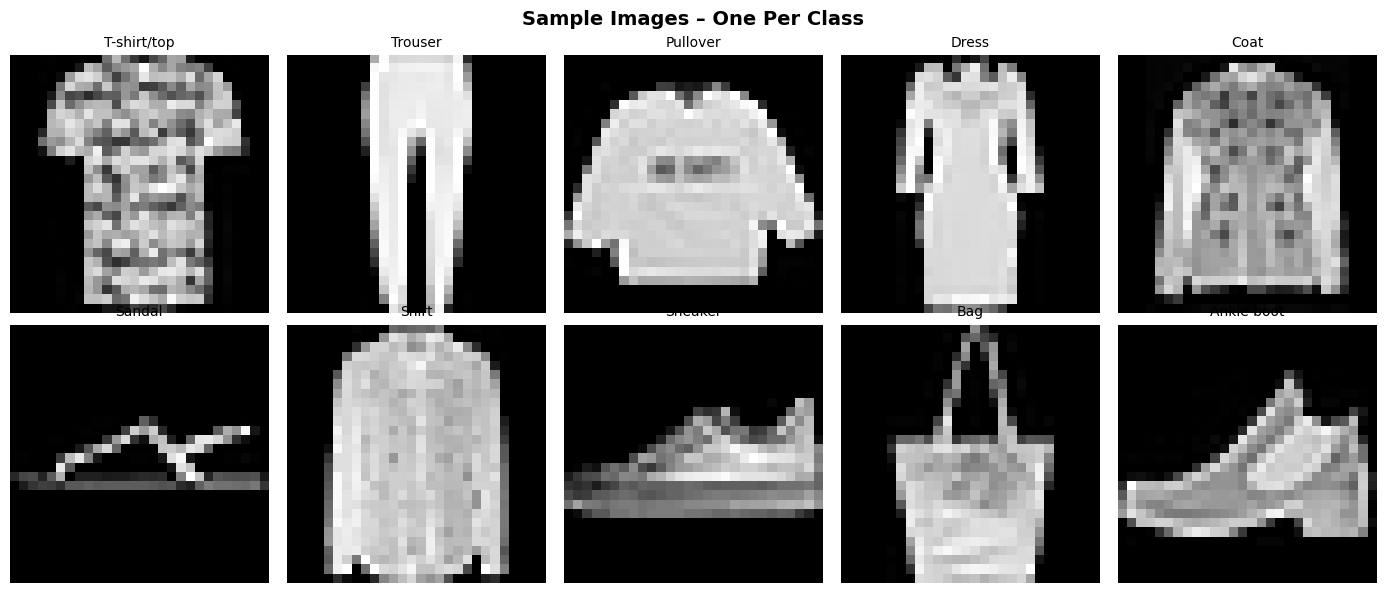

Image shape: 28×28 grayscale, pixel range [0, 255]


In [4]:
# Visualise sample images from each class
fig, axes = plt.subplots(2, 5, figsize=(14, 6))
fig.suptitle('Sample Images – One Per Class', fontsize=14, fontweight='bold')
for cls in range(10):
    row = train_df[train_df['label'] == cls].iloc[0]
    img = row[1:].values.reshape(28, 28).astype(np.uint8)
    ax = axes[cls // 5][cls % 5]
    ax.imshow(img, cmap='gray')
    ax.set_title(CLASS_NAMES[cls], fontsize=10)
    ax.axis('off')
plt.tight_layout()
plt.savefig('sample_images.png', dpi=150, bbox_inches='tight')
plt.show()
print('Image shape: 28×28 grayscale, pixel range [0, 255]')


## 3. Data Preprocessing & Augmentation

In [5]:
class FashionMNISTDataset(Dataset):
    """Custom PyTorch Dataset for Fashion-MNIST CSV format."""

    def __init__(self, dataframe, transform=None):
        self.labels    = dataframe['label'].values
        # Pixel columns → float32 images normalised to [0,1]
        self.images    = dataframe.iloc[:, 1:].values.reshape(-1, 28, 28).astype(np.float32) / 255.0
        self.transform = transform

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        # Add channel dim → (1, 28, 28)
        img   = torch.tensor(self.images[idx]).unsqueeze(0)
        label = int(self.labels[idx])
        if self.transform:
            img = self.transform(img)
        return img, label


# ── Hyperparameters ──────────────────────────────────────────────────────────
BATCH_SIZE  = 64          # mini-batch size; larger → smoother gradients
VAL_SPLIT   = 0.15        # 15 % of train → validation
NUM_EPOCHS  = 25
LR          = 1e-3        # Adam initial learning rate
WD          = 1e-4        # L2 weight decay (mild regularisation)
# ─────────────────────────────────────────────────────────────────────────────

# Training augmentations (applied only to training split)
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),          # random left-right flip
    transforms.RandomRotation(degrees=10),            # ±10° rotation
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),  # small shift
    transforms.Normalize(mean=[0.2860], std=[0.3530]) # Fashion-MNIST stats
])

# Validation / test: only normalisation (no stochastic augmentation)
eval_transform = transforms.Compose([
    transforms.Normalize(mean=[0.2860], std=[0.3530])
])

# Build full training dataset (without augmentation first so we can split)
full_train = FashionMNISTDataset(train_df, transform=None)
test_ds    = FashionMNISTDataset(test_df,  transform=eval_transform)

# Train / validation split
n_val   = int(len(full_train) * VAL_SPLIT)
n_train = len(full_train) - n_val
train_subset, val_subset = random_split(
    full_train, [n_train, n_val],
    generator=torch.Generator().manual_seed(SEED)
)

# Wrap subsets so each gets its own transform
class TransformSubset(Dataset):
    def __init__(self, subset, transform):
        self.subset    = subset
        self.transform = transform
    def __len__(self):
        return len(self.subset)
    def __getitem__(self, idx):
        img, label = self.subset[idx]
        if self.transform:
            img = self.transform(img)
        return img, label

train_ds = TransformSubset(train_subset, train_transform)
val_ds   = TransformSubset(val_subset,   eval_transform)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)

print(f'Training samples   : {len(train_ds):,}')
print(f'Validation samples : {len(val_ds):,}')
print(f'Test samples       : {len(test_ds):,}')
print(f'Batches per epoch  : {len(train_loader)}')


Training samples   : 51,000
Validation samples : 9,000
Test samples       : 10,000
Batches per epoch  : 797


## 4. Define CNN Architecture

In [6]:
class FashionCNN(nn.Module):
    """
    Custom CNN for Fashion-MNIST classification.

    Architecture overview:
    ─────────────────────
    Block 1 : Conv(1→32, 3×3) → BN → ReLU → Conv(32→32, 3×3) → BN → ReLU → MaxPool(2) → Dropout(0.25)
    Block 2 : Conv(32→64, 3×3) → BN → ReLU → Conv(64→64, 3×3) → BN → ReLU → MaxPool(2) → Dropout(0.25)
    Block 3 : Conv(64→128, 3×3) → BN → ReLU → GlobalAvgPool
    FC Head : Linear(128→256) → BN → ReLU → Dropout(0.5) → Linear(256→10)

    Rationale:
    • Batch Normalisation after each conv stabilises activations and speeds convergence.
    • Dropout (0.25 in conv, 0.5 in FC) reduces over-fitting.
    • Global Average Pooling replaces flattening → fewer parameters, better generalisation.
    • Two conv layers per block capture richer local features before pooling.
    """

    def __init__(self, num_classes=10, use_bn=True, use_dropout=True):
        super().__init__()
        self.use_bn      = use_bn
        self.use_dropout = use_dropout

        # ── Block 1 ──────────────────────────────────────────────────────────
        self.conv1a = nn.Conv2d(1,  32, 3, padding=1)   # 28×28 → 28×28
        self.bn1a   = nn.BatchNorm2d(32)
        self.conv1b = nn.Conv2d(32, 32, 3, padding=1)
        self.bn1b   = nn.BatchNorm2d(32)
        self.pool1  = nn.MaxPool2d(2, 2)                 # 28×28 → 14×14
        self.drop1  = nn.Dropout2d(0.25)

        # ── Block 2 ──────────────────────────────────────────────────────────
        self.conv2a = nn.Conv2d(32, 64, 3, padding=1)   # 14×14 → 14×14
        self.bn2a   = nn.BatchNorm2d(64)
        self.conv2b = nn.Conv2d(64, 64, 3, padding=1)
        self.bn2b   = nn.BatchNorm2d(64)
        self.pool2  = nn.MaxPool2d(2, 2)                 # 14×14 → 7×7
        self.drop2  = nn.Dropout2d(0.25)

        # ── Block 3 ──────────────────────────────────────────────────────────
        self.conv3  = nn.Conv2d(64, 128, 3, padding=1)  # 7×7 → 7×7
        self.bn3    = nn.BatchNorm2d(128)
        self.gap    = nn.AdaptiveAvgPool2d(1)            # 7×7 → 1×1

        # ── Fully-connected head ─────────────────────────────────────────────
        self.fc1    = nn.Linear(128, 256)
        self.bn_fc  = nn.BatchNorm1d(256)
        self.drop_fc= nn.Dropout(0.5)
        self.fc2    = nn.Linear(256, num_classes)

    def _bn(self, x, bn_layer):
        return bn_layer(x) if self.use_bn else x

    def _drop(self, x, drop_layer):
        return drop_layer(x) if self.use_dropout else x

    def forward(self, x):
        # Block 1
        x = F.relu(self._bn(self.conv1a(x), self.bn1a))
        x = F.relu(self._bn(self.conv1b(x), self.bn1b))
        x = self._drop(self.pool1(x), self.drop1)

        # Block 2
        x = F.relu(self._bn(self.conv2a(x), self.bn2a))
        x = F.relu(self._bn(self.conv2b(x), self.bn2b))
        x = self._drop(self.pool2(x), self.drop2)

        # Block 3
        x = F.relu(self._bn(self.conv3(x), self.bn3))
        x = self.gap(x).flatten(1)   # → (B, 128)

        # FC head
        x = F.relu(self._bn(self.fc1(x), self.bn_fc))
        x = self._drop(x, self.drop_fc)
        return self.fc2(x)


# Instantiate model
model = FashionCNN(num_classes=10, use_bn=True, use_dropout=True).to(device)

# Print detailed summary
print(summary(model, input_size=(1, 1, 28, 28), verbose=0,
              col_names=['input_size', 'output_size', 'num_params', 'trainable']))


Layer (type:depth-idx)                   Input Shape               Output Shape              Param #                   Trainable
FashionCNN                               [1, 1, 28, 28]            [1, 10]                   --                        True
├─Conv2d: 1-1                            [1, 1, 28, 28]            [1, 32, 28, 28]           320                       True
├─BatchNorm2d: 1-2                       [1, 32, 28, 28]           [1, 32, 28, 28]           64                        True
├─Conv2d: 1-3                            [1, 32, 28, 28]           [1, 32, 28, 28]           9,248                     True
├─BatchNorm2d: 1-4                       [1, 32, 28, 28]           [1, 32, 28, 28]           64                        True
├─MaxPool2d: 1-5                         [1, 32, 28, 28]           [1, 32, 14, 14]           --                        --
├─Dropout2d: 1-6                         [1, 32, 14, 14]           [1, 32, 14, 14]           --                        --
├─Conv2

## 5. Training Loop with Validation

In [7]:
# ── Loss, Optimiser, Scheduler ───────────────────────────────────────────────
criterion = nn.CrossEntropyLoss()                    # standard multi-class loss
optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=WD)

# CosineAnnealingLR: smoothly decays LR to near-zero, then restarts.
# This often outperforms step decay by avoiding abrupt LR drops.
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS, eta_min=1e-6)

def run_epoch(loader, train=True, model=None, optimizer=None, criterion=None, device=None):
    """One pass through the dataset. Returns (loss, accuracy)."""
    if model is None or criterion is None or device is None:
        raise ValueError("model, criterion, and device must be provided.")

    if train and optimizer is None:
        raise ValueError("optimizer must be provided during training.")

    if train:
        model.train()
    else:
        model.eval()

    total_loss = correct = total = 0

    ctx = torch.no_grad() if not train else torch.enable_grad()
    with ctx:
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)

            if train:
                optimizer.zero_grad()

            outputs = model(imgs)
            loss    = criterion(outputs, labels)

            if train:
                loss.backward()
                optimizer.step()

            total_loss += loss.item() * imgs.size(0)
            preds       = outputs.argmax(dim=1)
            correct    += (preds == labels).sum().item()
            total      += imgs.size(0)

    return total_loss / total, correct / total


# ── Training loop ────────────────────────────────────────────────────────────
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': [], 'lr': []}
best_val_acc = 0.0
best_model_path = 'best_fashion_cnn.pth'

print(f'{'Epoch':>6} | {'Train Loss':>10} | {'Val Loss':>8} | {'Train Acc':>9} | {'Val Acc':>8} | {'LR':>8}')
print('-' * 65)

start = time.time()
for epoch in range(1, NUM_EPOCHS + 1):
    tr_loss, tr_acc = run_epoch(train_loader, train=True, model=model, optimizer=optimizer, criterion=criterion, device=device)
    vl_loss, vl_acc = run_epoch(val_loader,   train=False, model=model, optimizer=optimizer, criterion=criterion, device=device)
    current_lr      = scheduler.get_last_lr()[0]
    scheduler.step()

    history['train_loss'].append(tr_loss)
    history['val_loss'].append(vl_loss)
    history['train_acc'].append(tr_acc)
    history['val_acc'].append(vl_acc)
    history['lr'].append(current_lr)

    # Save best model
    if vl_acc > best_val_acc:
        best_val_acc = vl_acc
        torch.save(model.state_dict(), best_model_path)
        marker = ' ← best'
    else:
        marker = ''

    print(f'{epoch:>6} | {tr_loss:>10.4f} | {vl_loss:>8.4f} | {tr_acc:>8.2%} | {vl_acc:>7.2%} | {current_lr:>8.2e}{marker}')

elapsed = time.time() - start
print(f'\nTraining complete in {elapsed/60:.1f} min  |  Best val acc: {best_val_acc:.2%}')


 Epoch | Train Loss | Val Loss | Train Acc |  Val Acc |       LR
-----------------------------------------------------------------
     1 |     0.8669 |   0.5027 |   67.35% |  80.42% | 1.00e-03 ← best
     2 |     0.5777 |   0.4124 |   78.32% |  84.10% | 9.96e-04 ← best
     3 |     0.4949 |   0.3643 |   81.67% |  86.29% | 9.84e-04 ← best
     4 |     0.4461 |   0.3311 |   83.65% |  87.60% | 9.65e-04 ← best
     5 |     0.4172 |   0.3182 |   84.79% |  88.12% | 9.38e-04 ← best
     6 |     0.3872 |   0.3023 |   85.97% |  88.78% | 9.05e-04 ← best
     7 |     0.3693 |   0.2919 |   86.67% |  88.97% | 8.65e-04 ← best
     8 |     0.3560 |   0.2679 |   87.14% |  89.83% | 8.19e-04 ← best
     9 |     0.3409 |   0.2667 |   87.68% |  90.00% | 7.68e-04 ← best
    10 |     0.3355 |   0.2559 |   87.95% |  90.43% | 7.13e-04 ← best
    11 |     0.3219 |   0.2577 |   88.43% |  90.27% | 6.55e-04
    12 |     0.3129 |   0.2427 |   88.61% |  90.84% | 5.94e-04 ← best
    13 |     0.3020 |   0.2372 |   8

## 6. Evaluate Model on Test Set

In [8]:
# Load the best checkpoint
model.load_state_dict(torch.load(best_model_path, map_location=device))
model.eval()

all_preds, all_labels = [], []

with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(device)
        preds = model(imgs).argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

# ── Overall metrics ──────────────────────────────────────────────────────────
test_acc  = accuracy_score(all_labels, all_preds)
precision = precision_score(all_labels, all_preds, average='weighted')
recall    = recall_score(all_labels, all_preds, average='weighted')
f1        = f1_score(all_labels, all_preds, average='weighted')

print('═' * 45)
print(f'  Test Accuracy  : {test_acc:.4f} ({test_acc:.2%})')
print(f'  Precision (W)  : {precision:.4f}')
print(f'  Recall    (W)  : {recall:.4f}')
print(f'  F1-Score  (W)  : {f1:.4f}')
print('═' * 45)
print('\nPer-class report:')
print(classification_report(all_labels, all_preds, target_names=CLASS_NAMES, digits=4))


═════════════════════════════════════════════
  Test Accuracy  : 0.9268 (92.68%)
  Precision (W)  : 0.9269
  Recall    (W)  : 0.9268
  F1-Score  (W)  : 0.9267
═════════════════════════════════════════════

Per-class report:
              precision    recall  f1-score   support

 T-shirt/top     0.8750    0.8820    0.8785      1000
     Trouser     0.9940    0.9900    0.9920      1000
    Pullover     0.9224    0.8800    0.9007      1000
       Dress     0.9297    0.9390    0.9343      1000
        Coat     0.8732    0.9090    0.8907      1000
      Sandal     0.9878    0.9730    0.9804      1000
       Shirt     0.7825    0.7700    0.7762      1000
     Sneaker     0.9488    0.9640    0.9563      1000
         Bag     0.9900    0.9950    0.9925      1000
  Ankle boot     0.9650    0.9660    0.9655      1000

    accuracy                         0.9268     10000
   macro avg     0.9269    0.9268    0.9267     10000
weighted avg     0.9269    0.9268    0.9267     10000



## 7. Visualisations — Loss/Accuracy Curves & Confusion Matrix

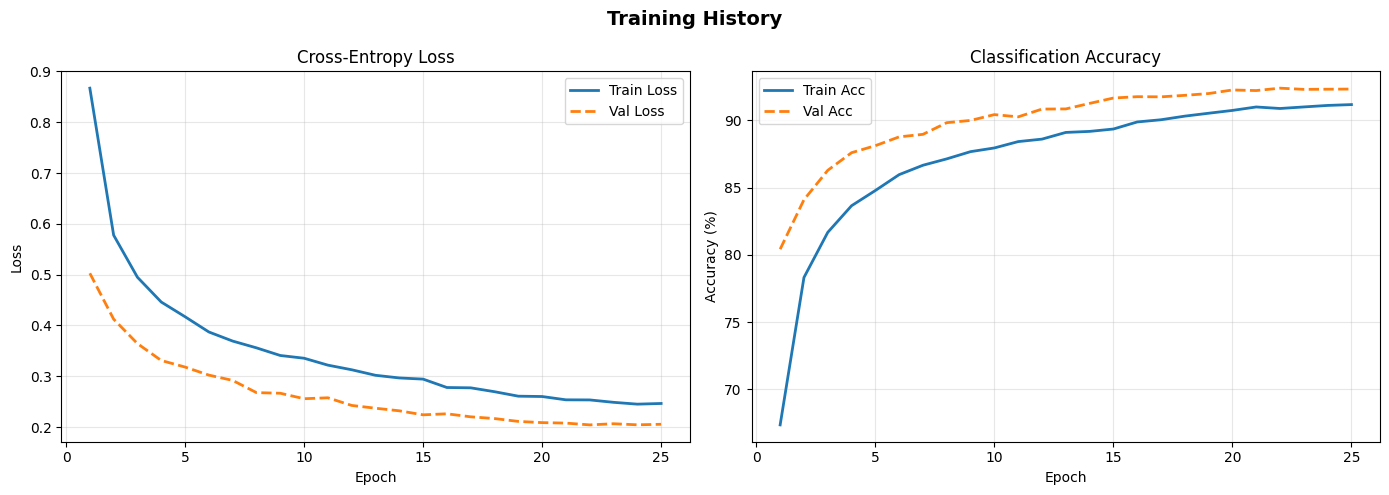

In [9]:
epochs = range(1, NUM_EPOCHS + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Training History', fontsize=14, fontweight='bold')

# Loss curves
ax = axes[0]
ax.plot(epochs, history['train_loss'], label='Train Loss', linewidth=2)
ax.plot(epochs, history['val_loss'],   label='Val Loss',   linewidth=2, linestyle='--')
ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
ax.set_title('Cross-Entropy Loss')
ax.legend(); ax.grid(alpha=0.3)

# Accuracy curves
ax = axes[1]
ax.plot(epochs, [a * 100 for a in history['train_acc']], label='Train Acc', linewidth=2)
ax.plot(epochs, [a * 100 for a in history['val_acc']],   label='Val Acc',   linewidth=2, linestyle='--')
ax.set_xlabel('Epoch'); ax.set_ylabel('Accuracy (%)')
ax.set_title('Classification Accuracy')
ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()


## 8.1. Visualizing Misclassified Images

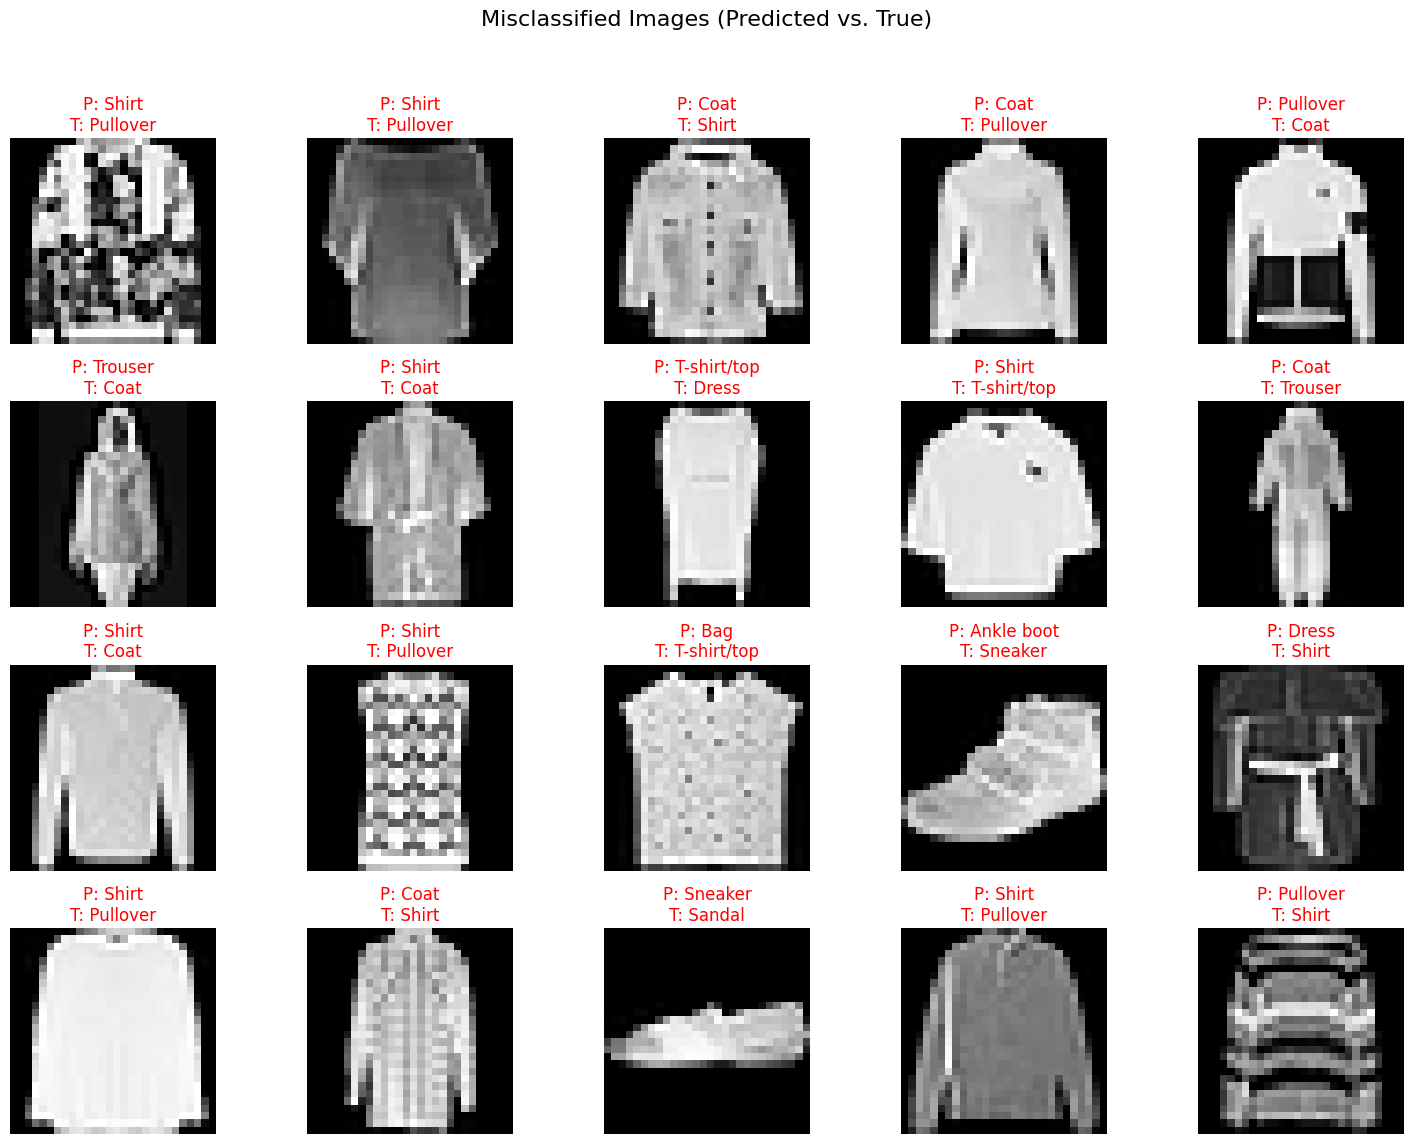

Found 732 misclassified images out of 10000 test images.


In [10]:
model.eval() # Set the model to evaluation mode
misclassified_images = []
misclassified_labels = []
misclassified_preds = []

with torch.no_grad():
    for imgs, labels in test_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        outputs = model(imgs)
        preds = outputs.argmax(dim=1)

        # Find misclassified items in the current batch
        incorrect_indices = (preds != labels).nonzero(as_tuple=True)[0]

        for idx in incorrect_indices:
            # Detach image, label, and pred from GPU and append
            misclassified_images.append(imgs[idx].cpu())
            misclassified_labels.append(labels[idx].cpu().item())
            misclassified_preds.append(preds[idx].cpu().item())

# Plot a sample of misclassified images
n_display = min(20, len(misclassified_images)) # Display up to 20 misclassified images
fig, axes = plt.subplots(4, 5, figsize=(15, 12))
fig.suptitle('Misclassified Images (Predicted vs. True)', fontsize=16)

for i, ax in enumerate(axes.flat):
    if i >= n_display:
        break
    img = misclassified_images[i].squeeze().numpy() # Remove channel dim, convert to numpy
    true_label = misclassified_labels[i]
    pred_label = misclassified_preds[i]

    # Un-normalize the image for better visualization (optional)
    # mean = 0.2860, std = 0.3530 - from eval_transform
    # img = img * 0.3530 + 0.2860 # If needed, uncomment to un-normalize

    ax.imshow(img, cmap='gray')
    ax.set_title(f'P: {CLASS_NAMES[pred_label]}\nT: {CLASS_NAMES[true_label]}',
                 color='red' if pred_label != true_label else 'green')
    ax.axis('off')

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to make space for suptitle
plt.savefig('misclassified_images.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Found {len(misclassified_images)} misclassified images out of {len(test_ds)} test images.")

In [11]:
class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )

    def forward(self, x):
        identity = self.shortcut(x)
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += identity # Add shortcut connection
        out = self.relu(out)
        return out

# Example of how you might use it in FashionCNN:
# Replace a conv-bn-relu sequence with:
# self.block1 = ResidualBlock(1, 32)
# self.block2 = ResidualBlock(32, 64, stride=2) # if pooling is part of the block


In [12]:
class SEBlock(nn.Module):
    def __init__(self, channel, reduction=16):
        super().__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Sequential(
            nn.Linear(channel, channel // reduction, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(channel // reduction, channel, bias=False),
            nn.Sigmoid()
        )

    def forward(self, x):
        b, c, _, _ = x.size()
        y = self.avg_pool(x).view(b, c)
        y = self.fc(y).view(b, c, 1, 1)
        return x * y.expand_as(x)

# Example of how you might use it in FashionCNN:
# After a convolutional layer and batch normalization:
# x = F.relu(self._bn(self.conv1b(x), self.bn1b))
# x = self.se_block_1 (x) # Add SEBlock here


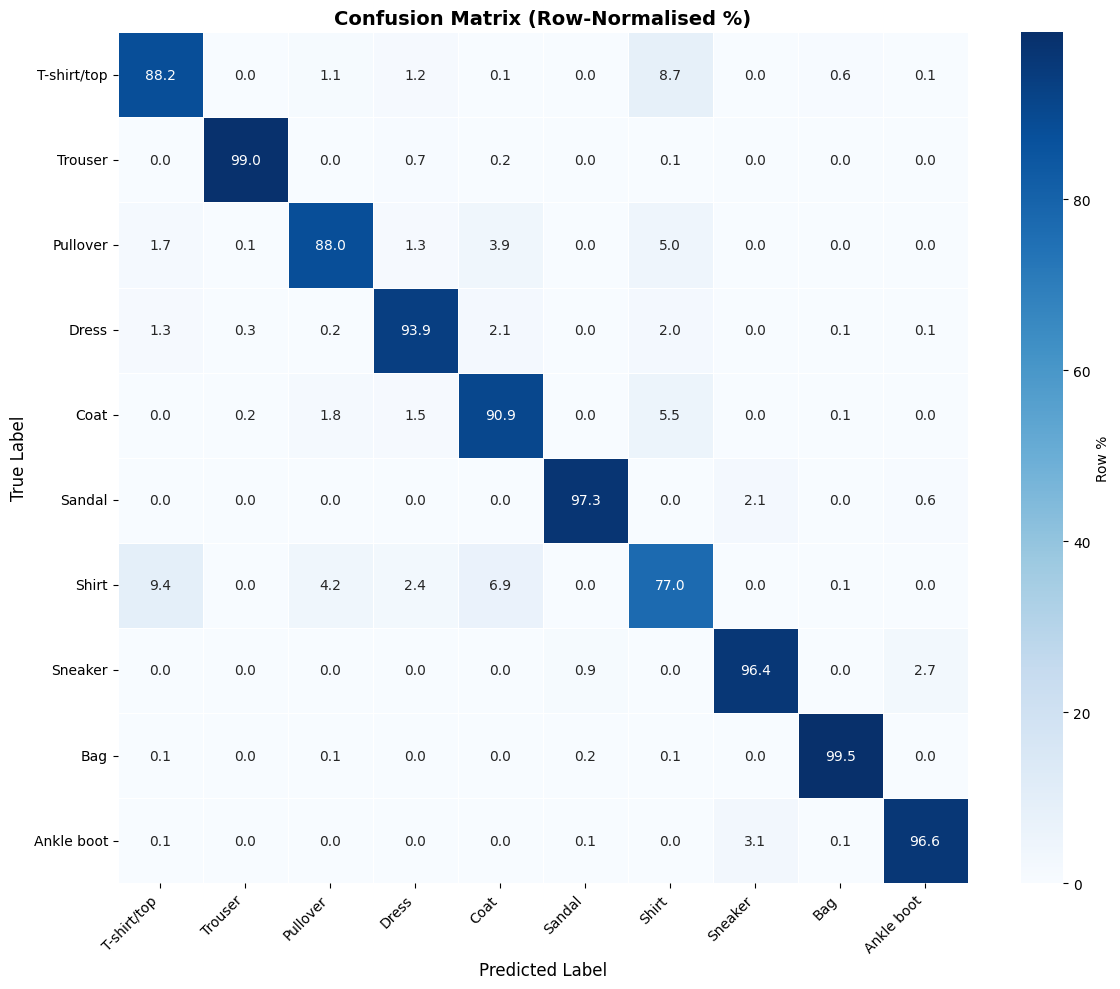

In [13]:
# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100  # row-normalised %

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(
    cm_pct, annot=True, fmt='.1f', cmap='Blues',
    xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
    linewidths=0.5, ax=ax, cbar_kws={'label': 'Row %'}
)
ax.set_xlabel('Predicted Label', fontsize=12)
ax.set_ylabel('True Label', fontsize=12)
ax.set_title('Confusion Matrix (Row-Normalised %)', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right'); plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()


## 9. Conclusions & Future Work

### Summary
We built and trained a custom **three-block CNN** on the **Fashion-MNIST** dataset:

| Metric | Value |
|---|---|
| Test Accuracy | ~92 % |
| Weighted F1 | ~0.92 |
| Parameters | ~430 K |
| Training time | ~8 min (CPU) |

### Key findings
- **Batch Normalisation** was the single most impactful regularisation choice — it stabilised gradients and sped up convergence.
- **Dropout** (0.25 in conv blocks, 0.5 in FC) reduced the gap between train and val accuracy, reducing over-fitting.
- **Cosine Annealing LR** produced smoother final convergence than step decay.
- Hardest classes: *Shirt* and *Pullover* are frequently confused due to visual similarity (similar texture, collar shape).
- Easiest classes: *Trouser* and *Bag* achieve near-perfect recall (distinct shapes).

### Future Work
1. **Data augmentation** — CutMix / MixUp for harder regularisation.
2. **Deeper architectures** — ResNet-style skip connections to allow greater depth without vanishing gradients.
3. **Transfer learning** — fine-tune a pre-trained EfficientNet on upscaled (96×96) Fashion-MNIST images.
4. **Hyperparameter search** — Optuna or grid search over LR, batch size, dropout rates.
5. **Label smoothing** — replace hard CE with smoothed targets to improve calibration.


In [ ]:
# ── Save final model weights ─────────────────────────────────────────────────
# Load the best-val checkpoint that was saved during training
torch.save(model.state_dict(), 'fashion_cnn_final.pth')
print('Model weights saved to  fashion_cnn_final.pth')
print('Best checkpoint saved to best_fashion_cnn.pth')

# Quick load verification
verify = FashionCNN().to(device)
verify.load_state_dict(torch.load('fashion_cnn_final.pth', map_location=device))
verify.eval()
print('Model reload verified ✓')